# Parallel vs sequential chunk execution (coffea-casa)

`coffea-workflow` splits the fileset into workflow-level *chunks* (sub-filesets), each processed and cached independently. `ExecutorConfig(parallel_chunks=...)` controls how those chunks are dispatched to the Dask cluster:

```
Sequential  (parallel_chunks=False, default)
────────────────────────────────────────────
  chunk 0  [files → DaskExecutor: all workers] → cached
  chunk 1  [files → DaskExecutor: all workers] → cached
  ...      one chunk at a time; workers collaborate inside each chunk

Parallel  (parallel_chunks=True)
────────────────────────────────────────────
  chunk 0 ─┐
  chunk 1 ─┼─ client.submit() — all chunks at once, one worker per chunk
  ...     ─┘  (each worker runs its chunk with a local IterativeExecutor)
```

**The physics result is identical either way** — verified below. What changes is wall time and worker utilization. Run inside a coffea-casa JupyterLab session.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import sys

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, run
from coffea_workflow import facilities
from ttbar_analysis import get_fileset, run_analysis, plotting_1

In [2]:
def build_workflow():
    
    step_fileset = Step(
        name="Fileset_ttbar",
        step_type=Fileset,
        builder=get_fileset,
        builder_params={"with_failure": False,
                        "n_files_max_per_sample": 2},
        output="fileset_dict",
    )
    step_analysis = Step(
        name="Analysis_ttbar",
        step_type=Analysis,
        builder=run_analysis,
        builder_params={"use_inference": False},
        input="fileset_dict",
        output="analysis_payload",
    )
    step_plotting = Step(
        name="Plot_ttbar",
        step_type=Plotting,
        builder=plotting_1,
        input="analysis_payload",
    )
    wf = Workflow()
    wf.add(step_fileset)
    wf.add(step_analysis, depends_on=[step_fileset])
    wf.add(step_plotting, depends_on=[step_analysis])
    return wf

In [3]:
# shared facility — reused by both runs below
facility = facilities.CoffeaCasaFactory(
    worker_packages=("coffea>=2026.7.0", ),
    worker_files=("ttbar_analysis.py", "utils", "corrections.json", "nanoaod_inputs.json"),
)

## Strategy 1 — sequential (`parallel_chunks=False`, default)

`by_dataset` + `percentage=50` → 18 chunks (9 datasets × 2). Chunks run one after another; within each chunk, Dask workers share the file-reading and event-processing tasks.

Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7f76a511de40>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7f76a511e0c0>
  [2] Plot_ttbar -> Plotting builder=<function plotting_1 at 0x7f76a518e2a0>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7f76a511de40> and user parameters {'with_failure': False, 'n_files_max_per_sample': 2}
processes in fileset: ['ttbar__nominal', 'ttbar__scaledown', 'ttbar__scaleup', 'ttbar__ME_var', 'ttbar__PS_var', 'single_top_s_chan__nominal', 'single_top_t_chan__nominal', 'single_top_tW__nominal', 'wjets__nominal']

example of information in fileset:
['https://xrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/ST_s-channel_4f_InclusiveDecays_13TeV-amcatnlo-pythia8/cmsopendata2015

Output()

Output()

Output()


execution took 12.35 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_1.json


...

Output()

Output()


execution took 23.11 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_3.json


Output()


execution took 21.55 seconds
Successfully processed!
  -> materialized at .cache_sequential/Analysis/e45a8c485debe1f1f630364a9d65712795cee16b4524e2aea433ded3edd98eb8

Executing step 'Plot_ttbar' of type 'Plotting' with the user code <function plotting_1 at 0x7f76a518e2a0> and user parameters None
dict_keys(['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result'])
  -> materialized at .cache_sequential/Plotting/ee1ef25ccd0ddb51dabba5aaf468a05b07b9b0d27b76165e44c92eccd383d8fd


=== Run Summary ===
  ✓  Fileset_ttbar                  Fileset
  ✓  Analysis_ttbar                 Analysis             4/4 chunks OK
  ✓  Plot_ttbar                     Plotting


Sequential wall time: 98.9s


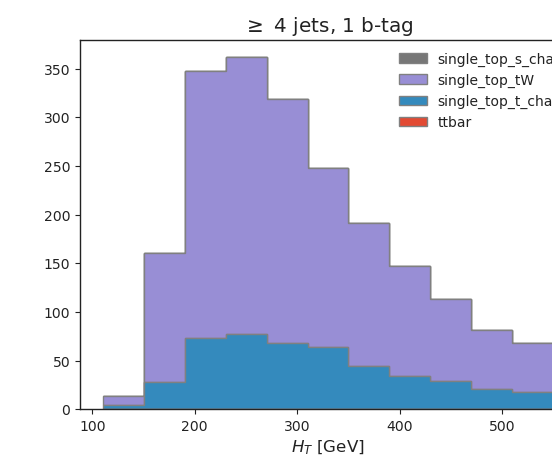

2026-07-16 15:25:32,707 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [4]:
config_sequential = RunConfig(
    strategy="by_dataset",
    chunk_fraction=0.50,
    cache_dir=".cache_sequential",
    facility=facility,
    executor_config=ExecutorConfig(
        executor_type="DaskExecutor",
        parallel_chunks=False,
    ),
)

t0 = time.perf_counter()
result_sequential = run(build_workflow(), config_sequential)
t_sequential = time.perf_counter() - t0

print(f"\nSequential wall time: {t_sequential:.1f}s")

## Strategy 2 — parallel chunks (`parallel_chunks=True`)

All 18 uncached chunks are submitted to the workers at once via `client.submit()`. `executor_type="DaskExecutor"` is still required — it provides the client used for submission; on each worker the chunk runs with a local `IterativeExecutor`.

Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7f76a511de40>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7f76a511e0c0>
  [2] Plot_ttbar -> Plotting builder=<function plotting_1 at 0x7f76a518e2a0>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7f76a511de40> and user parameters {'with_failure': False, 'n_files_max_per_sample': 2}
processes in fileset: ['ttbar__nominal', 'ttbar__scaledown', 'ttbar__scaleup', 'ttbar__ME_var', 'ttbar__PS_var', 'single_top_s_chan__nominal', 'single_top_t_chan__nominal', 'single_top_tW__nominal', 'wjets__nominal']

example of information in fileset:
['https://xrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/ST_s-channel_4f_InclusiveDecays_13TeV-amcatnlo-pythia8/cmsopendata2015

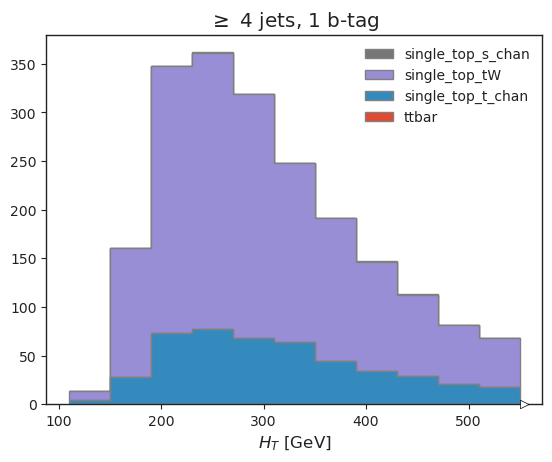

2026-07-16 15:25:32,709 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [5]:
config_parallel = RunConfig(
    strategy="by_dataset",
    chunk_fraction=0.5,
    cache_dir=".cache_parallel",
    facility=facility,
    executor_config=ExecutorConfig(
        executor_type="DaskExecutor",
        parallel_chunks=True,
    ),
)

t0 = time.perf_counter()
result_parallel = run(build_workflow(), config_parallel)
t_parallel = time.perf_counter() - t0

print(f"\nParallel wall time: {t_parallel:.1f}s")

Sequential wall time :   98.9s
Parallel wall time   :  140.9s
Speed-up             : 0.70x


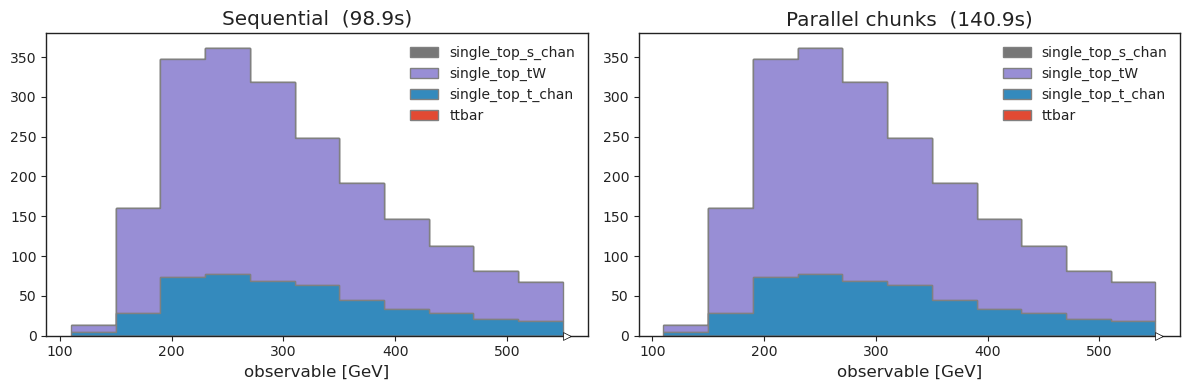

In [7]:
print("=" * 42)
print(f"Sequential wall time : {t_sequential:6.1f}s")
print(f"Parallel wall time   : {t_parallel:6.1f}s")
if t_parallel > 0:
    print(f"Speed-up             : {t_sequential / t_parallel:.2f}x")
print("=" * 42)

hists_seq, _ = result_sequential["results"]["Analysis_ttbar"]["processor_result"]
hists_par, _ = result_parallel["results"]["Analysis_ttbar"]["processor_result"]

h_seq = hists_seq["hist_dict"]["4j1b"]
h_par = hists_par["hist_dict"]["4j1b"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h, label, t in [(axes[0], h_seq, "Sequential", t_sequential),
                        (axes[1], h_par, "Parallel chunks", t_parallel)]:
    h[120j::2j, :, "nominal"].stack("process")[::-1].plot(
        stack=True, histtype="fill", linewidth=1, edgecolor="grey", ax=ax
    )
    ax.legend(frameon=False)
    ax.set_title(f"{label}  ({t:.1f}s)")
plt.tight_layout()

In [9]:
def processed_summary(result, label):
    analysis = result["results"]["Analysis_ttbar"]
    hists, metrics = analysis["processor_result"]
    print(f"{label}: {int(metrics['entries']):,} events processed "
          f"in {analysis['n_chunks_ok']}/{analysis['n_chunks_total']} chunks run")
    for ds, n in sorted(hists["nevents"].items()):
        print(f"    {ds}: {n:,}")

processed_summary(result_sequential, "Sequential")
processed_summary(result_parallel,  "\nParallel")

Sequential: 6,195,332 events processed in 4/4 chunks run
    single_top_s_chan__nominal: 139,300
    single_top_tW__nominal: 999,400
    single_top_t_chan__nominal: 2,428,832
    ttbar__ME_var: 2,627,800

Parallel: 6,195,332 events processed in 4/4 chunks run
    single_top_s_chan__nominal: 139,300
    single_top_tW__nominal: 999,400
    single_top_t_chan__nominal: 2,428,832
    ttbar__ME_var: 2,627,800


**Sequential**: 98.9s 

**Parallel**: 140.9s (0.70×)

same 6,195,332 events, same 4 chunks, identical histograms, 4 workers in both runs.

Parallel dispatch loses here, and the chunk table shows why: the workload is 4 heavily unbalanced chunks on 4 workers. The largest chunk (ttbar__ME_var, 2.6M events) carries ~42% of all events; the smallest (single_top_s_chan, 139k) about 2%.


Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7f76a511de40>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7f76a511e0c0>
  [2] Plot_ttbar -> Plotting builder=<function plotting_1 at 0x7f76a518e2a0>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7f76a511de40> and user parameters {'with_failure': False, 'n_files_max_per_sample': 2}
processes in fileset: ['ttbar__nominal', 'ttbar__scaledown', 'ttbar__scaleup', 'ttbar__ME_var', 'ttbar__PS_var', 'single_top_s_chan__nominal', 'single_top_t_chan__nominal', 'single_top_tW__nominal', 'wjets__nominal']

example of information in fileset:
['https://xrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/ST_s-channel_4f_InclusiveDecays_13TeV-amcatnlo-pythia8/cmsopendata2015

Output()

Installing on workers: ['coffea>=2026.7.0']
------------------------------------
Processing fileset_chunk_0.json


Output()

Output()

...

Output()

Output()


execution took 25.78 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_16.json


Output()


execution took 28.34 seconds
Successfully processed!
  -> materialized at .cache_sequential_50/Analysis/e45a8c485debe1f1f630364a9d65712795cee16b4524e2aea433ded3edd98eb8

Executing step 'Plot_ttbar' of type 'Plotting' with the user code <function plotting_1 at 0x7f76a518e2a0> and user parameters None
dict_keys(['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result'])
  -> materialized at .cache_sequential_50/Plotting/ee1ef25ccd0ddb51dabba5aaf468a05b07b9b0d27b76165e44c92eccd383d8fd


=== Run Summary ===
  ✓  Fileset_ttbar                  Fileset
  ✓  Analysis_ttbar                 Analysis             9/9 chunks OK
  ✓  Plot_ttbar                     Plotting


Sequential wall time: 233.1s


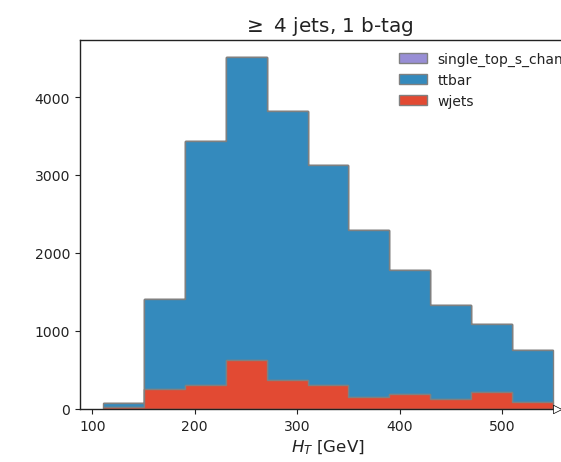

In [14]:
config_sequential_50 = RunConfig(
    strategy="by_dataset",
    percentage=50,
    chunk_fraction=0.50,
    cache_dir=".cache_sequential_50",
    facility=facility,
    executor_config=ExecutorConfig(
        executor_type="DaskExecutor",
        parallel_chunks=False,
    ),
)

t0_50 = time.perf_counter()
result_sequential_50 = run(build_workflow(), config_sequential_50)
t_sequential_50 = time.perf_counter() - t0_50

print(f"\nSequential wall time: {t_sequential_50:.1f}s")

Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7f76a511de40>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7f76a511e0c0>
  [2] Plot_ttbar -> Plotting builder=<function plotting_1 at 0x7f76a518e2a0>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7f76a511de40> and user parameters {'with_failure': False, 'n_files_max_per_sample': 2}
processes in fileset: ['ttbar__nominal', 'ttbar__scaledown', 'ttbar__scaleup', 'ttbar__ME_var', 'ttbar__PS_var', 'single_top_s_chan__nominal', 'single_top_t_chan__nominal', 'single_top_tW__nominal', 'wjets__nominal']

example of information in fileset:
['https://xrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/ST_s-channel_4f_InclusiveDecays_13TeV-amcatnlo-pythia8/cmsopendata2015

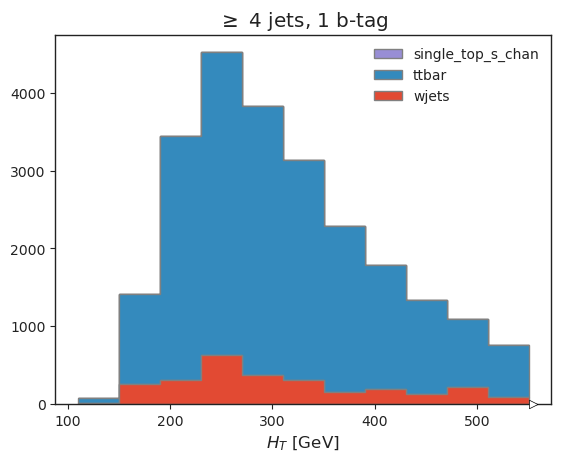

In [15]:
config_parallel_50 = RunConfig(
    strategy="by_dataset",
    percentage=50,
    chunk_fraction=0.50,
    cache_dir=".cache_parallel_50",
    facility=facility,
    executor_config=ExecutorConfig(
        executor_type="DaskExecutor",
        parallel_chunks=True,
    ),
)

t0_50 = time.perf_counter()
result_parallel_50 = run(build_workflow(), config_parallel_50)
t_parallel_50 = time.perf_counter() - t0_50

print(f"\nParallel wall time: {t_parallel_50:.1f}s")

Sequential wall time :  233.1s
Parallel wall time   :  111.8s
Speed-up             : 2.08x


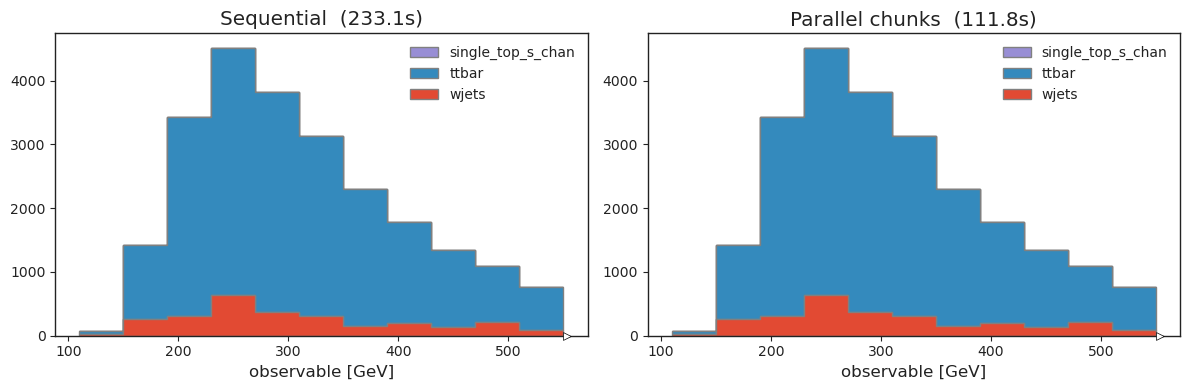

In [18]:
print("=" * 42)
print(f"Sequential wall time : {t_sequential_50:6.1f}s")
print(f"Parallel wall time   : {t_parallel_50:6.1f}s")
if t_parallel_50 > 0:
    print(f"Speed-up             : {t_sequential_50 / t_parallel_50:.2f}x")
print("=" * 42)

hists_seq, _ = result_sequential_50["results"]["Analysis_ttbar"]["processor_result"]
hists_par, _ = result_parallel_50["results"]["Analysis_ttbar"]["processor_result"]

h_seq = hists_seq["hist_dict"]["4j1b"]
h_par = hists_par["hist_dict"]["4j1b"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h, label, t in [(axes[0], h_seq, "Sequential", t_sequential_50),
                        (axes[1], h_par, "Parallel chunks", t_parallel_50)]:
    h[120j::2j, :, "nominal"].stack("process")[::-1].plot(
        stack=True, histtype="fill", linewidth=1, edgecolor="grey", ax=ax
    )
    ax.legend(frameon=False)
    ax.set_title(f"{label}  ({t:.1f}s)")
plt.tight_layout()

In [27]:
import cloudpickle
from pathlib import Path

def chunk_sizes(config, label):
    print(f"--- {label}")
    total = 0
    for payload in sorted(Path(config.cache_dir).glob("ChunkAnalysis/*/payload.pkl")):
        r = cloudpickle.loads(payload.read_bytes())
        if r.is_ok():
            hists, metrics = r.unwrap()
            n = int(metrics["entries"])
            total += n
            print(f"  {payload.parent.name[:10]}…  {n:>12,} events   [{', '.join(hists['nevents'])}]")
        else:
            print(f"  {payload.parent.name[:10]}…  FAILED: {r}")
    print(f"  {'total':<12} {total:>12,} events")

chunk_sizes(config_sequential_50, "Sequential")
print()
chunk_sizes(config_parallel_50,  "Parallel")
        

--- Sequential
  1f165721e5…       139,200 events   [single_top_s_chan__nominal]
  455fb17f4f…     1,334,428 events   [ttbar__nominal]
  5b37a69cd9…     1,257,883 events   [ttbar__scaleup]
  7703475dbf…     1,287,295 events   [ttbar__scaledown]
  8c0c987c88…     1,268,248 events   [ttbar__scaledown]
  9af1c82624…     1,297,266 events   [ttbar__nominal]
  ac8d9f93fa…     1,278,695 events   [ttbar__scaleup]
  ef1f05f8cb…     1,249,076 events   [wjets__nominal]
  f7311642f2…           100 events   [single_top_s_chan__nominal]
  total           9,112,191 events

--- Parallel
  1f165721e5…       139,200 events   [single_top_s_chan__nominal]
  455fb17f4f…     1,334,428 events   [ttbar__nominal]
  5b37a69cd9…     1,257,883 events   [ttbar__scaleup]
  7703475dbf…     1,287,295 events   [ttbar__scaledown]
  8c0c987c88…     1,268,248 events   [ttbar__scaledown]
  9af1c82624…     1,297,266 events   [ttbar__nominal]
  ac8d9f93fa…     1,278,695 events   [ttbar__scaleup]
  ef1f05f8cb…     1,249,076 